In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

from tqdm import tqdm
from scipy.stats import spearmanr, zscore

In [ ]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "integrated_with_quiescence.h5ad")

In [7]:
adata_full.layers["counts"] = adata_full.X.copy()

In [8]:
adata = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()

In [9]:
adata.obs = adata.obs.rename(
    columns={"QuiescenceScore": "quiescence_score", "QuiescenceStatus": "cycling_state"}
)

# replace values in QuiescenceStatus
adata.obs["cycling_state"] = adata.obs["cycling_state"].replace(
    {"Quiescent": "G0-arrested", "Proliferating": "Fast-cycling"}
)

In [10]:
adata = adata[adata.obs["type"].isin(["ER", "PR", "HER", "TNBC", "DCIS", "neoplasm"])].copy()

In [11]:
adata.layers["counts"] = adata.X.copy()

In [12]:
sc.pp.filter_genes(adata, min_cells=20)

filtered out 8674 genes that are detected in less than 20 cells


In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

normalizing counts per cell
    finished (0:00:01)


In [14]:
edu_proxy_genes = [
    "PCNA", "TK1", "RRM2", "RRM1", "MCM2", "MCM3", "MCM4", "MCM5", "MCM6",
    "MCM7", "CDC6", "CDC45", "ORC1", "ORC2", "POLE", "POLD1", "POLD3",
    "PRIM1", "PRIM2", "RPA1", "RPA2", "FEN1", "LIG1", "RFC4", "TOP2A",
    "CCNA2", "CCNE1", "GMNN", "HIST1H4C", "DNA2",
]

expr_df = pd.DataFrame(adata.X.toarray().T, index=adata.var_names, columns=adata.obs_names)

In [15]:
# # Filter gene sets for intersection with available genes
edu_proxy_genes = [g for g in edu_proxy_genes if g in expr_df.index]

# Z-score per gene across cells
expr_z = pd.DataFrame(
    zscore(expr_df.values, axis=1, nan_policy="omit"),
    index=expr_df.index,
    columns=expr_df.columns,
)

# Store in adata.obs
adata.obs["edu_score"] = expr_z.loc[edu_proxy_genes].sum(axis=0) / np.sqrt(
    len(edu_proxy_genes)
)

In [16]:
def quiescence_score(
    adata,
    up_genes: list,
    down_genes: list,
    layer: str | None = None,
    key_added: str = "quiescence_score",
):
    """Calculate quiescence scores from an AnnData object (genes in var, cells in obs).

    Parameters
    ----------
    adata : AnnData
        AnnData object containing expression matrix (adata.X or adata.layers[layer]).
    up_genes : list of str
        Genes upregulated in quiescent cells.
    down_genes : list of str
        Genes downregulated in quiescent cells.
    layer : str or None, optional (default: None)
        Layer in `adata.layers` to use instead of `adata.X`.
    key_added : str, optional (default: "quiescence_score")
        Key under which to store the resulting scores in `adata.obs`.

    Returns
    -------
    pd.Series
        Quiescence score per cell (also stored in `adata.obs[key_added]`).
    """
    import numpy as np
    import pandas as pd
    from scipy.stats import zscore

    # Select expression matrix
    if layer is None:
        X = adata.X
    else:
        if layer not in adata.layers:
            raise ValueError(f"Layer '{layer}' not found in adata.layers.")
        X = adata.layers[layer]

    # Ensure dense
    if not isinstance(X, np.ndarray):
        X = X.toarray()

    expr_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)

    # Filter gene sets for intersection with available genes
    up_genes = [g for g in up_genes if g in expr_df.index]
    down_genes = [g for g in down_genes if g in expr_df.index]

    if not up_genes or not down_genes:
        raise ValueError("No overlap between signature genes and adata.var_names.")

    # Z-score per gene across cells
    expr_z = pd.DataFrame(
        zscore(expr_df.values, axis=1, nan_policy="omit"),
        index=expr_df.index,
        columns=expr_df.columns,
    )

    # Compute gene set means scaled by sqrt(gene count)
    up_score = expr_z.loc[up_genes].sum(axis=0) / np.sqrt(len(up_genes))
    down_score = expr_z.loc[down_genes].sum(axis=0) / np.sqrt(len(down_genes))
    score = up_score - down_score
    score.name = key_added

    # Store in adata.obs
    adata.obs[key_added] = score

In [17]:
with open("gene_sets.pkl", "rb") as f:
    gene_sets = pickle.load(f)

quiescence_score(
    adata,
    gene_sets["upregulated"],
    gene_sets["downregulated"],
    key_added="oren_quiescence",
)

In [18]:
# Step 1: Filter valid cells (non-NaN)
valid_mask = adata.obs[["oren_quiescence", "edu_score"]].notna().all(axis=1)
qs_vals = adata.obs.loc[valid_mask, "oren_quiescence"].values
edu_vals = adata.obs.loc[valid_mask, "edu_score"].values
n_valid = valid_mask.sum()

# Step 2: Define stricter cut-off ranges
cutoff_range_lower = np.linspace(np.percentile(qs_vals, 1), -0.01, 50)
cutoff_range_upper = np.linspace(
    np.percentile(qs_vals, 70), np.percentile(qs_vals, 99), 50
)

# Step 3: Initialise
best_score = -np.inf
best_lower = None
best_upper = None

# For plotting
score_records = []

# Step 4: Grid search
for lower in tqdm(cutoff_range_lower):
    for upper in cutoff_range_upper:
        if upper <= lower + 0.05:
            continue

        cats = np.full(n_valid, "Slow-cycling", dtype=object)
        cats[qs_vals <= lower] = "Fast-cycling"
        cats[qs_vals >= upper] = "G0-arrested"

        df_valid = pd.DataFrame(
            {
                "oren_quiescence": qs_vals,
                "edu_score": edu_vals,
                "cycling_state_oren": cats,
            }
        )

        df_fast = df_valid[df_valid["cycling_state_oren"] == "Fast-cycling"]
        df_g0 = df_valid[df_valid["cycling_state_oren"] == "G0-arrested"]
        df_slow = df_valid[df_valid["cycling_state_oren"] == "Slow-cycling"]

        if any(len(g) < 0.05 * n_valid for g in [df_fast, df_g0, df_slow]):
            continue

        try:
            corr_fast = spearmanr(-df_fast["oren_quiescence"], df_fast["edu_score"])[0]
            corr_g0 = spearmanr(df_g0["oren_quiescence"], df_g0["edu_score"])[0]
        except ValueError:
            continue

        score = corr_fast - corr_g0
        score_records.append((lower, upper, score))

        if score > best_score:
            best_score = score
            best_lower = lower
            best_upper = upper

# Convert records to DataFrame for plotting
df_scores = pd.DataFrame(score_records, columns=["lower", "upper", "score"])

# Step 5: Assign final categories to all cells
def assign_cycling_state(row):
    q = row["oren_quiescence"]
    e = row["edu_score"]
    if pd.isna(q) or pd.isna(e):
        return "Unknown"
    if q <= best_lower:
        return "Fast-cycling"
    elif q >= best_upper:
        return "G0-arrested"
    else:
        return "Slow-cycling"


adata.obs["cycling_state_oren"] = adata.obs.apply(assign_cycling_state, axis=1)

# Step 6: Report
print("Final optimised cut-offs:")
print(f" Fast-cycling ≤ {best_lower:.3f}")
print(f" G0-arrested ≥ {best_upper:.3f}")
print(f" Total correlation score: {best_score:.3f}")
print(adata.obs["cycling_state_oren"].value_counts())

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:23<00:00,  1.68s/it]


Final optimised cut-offs:
 Fast-cycling ≤ -1.054
 G0-arrested ≥ 3.429
 Total correlation score: 0.448
cycling_state_oren
Slow-cycling    56424
Fast-cycling    23187
G0-arrested      6138
Name: count, dtype: int64


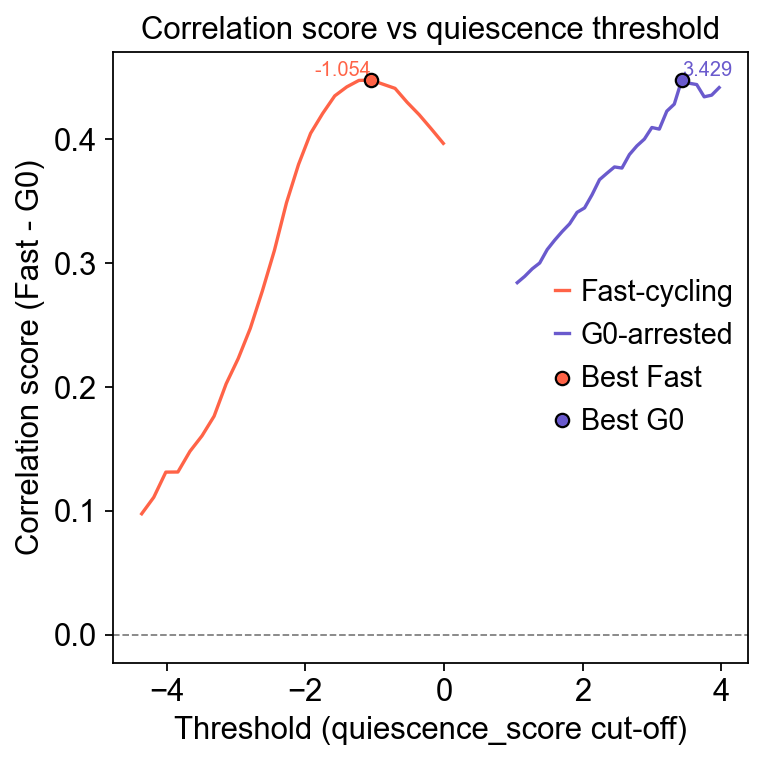

In [21]:
# Aggregate scores for both lower (fast) and upper (G0)
df_lower_score = df_scores.groupby("lower", as_index=False)["score"].max()
df_lower_score["threshold_type"] = "Fast-cycling"
df_lower_score.rename(columns={"lower": "threshold"}, inplace=True)

df_upper_score = df_scores.groupby("upper", as_index=False)["score"].max()
df_upper_score["threshold_type"] = "G0-arrested"
df_upper_score.rename(columns={"upper": "threshold"}, inplace=True)

# Combine into a single DataFrame
df_combined = pd.concat([df_lower_score, df_upper_score], ignore_index=True)

# Plot
plt.figure(figsize=(5, 5))
sns.lineplot(
    data=df_combined,
    x="threshold",
    y="score",
    hue="threshold_type",
    palette={"Fast-cycling": "tomato", "G0-arrested": "slateblue"},
)

# Highlight and annotate best Fast-cycling point
plt.scatter(
    best_lower,
    best_score,
    color="tomato",
    edgecolor="black",
    zorder=5,
    label="Best Fast",
)
plt.text(
    best_lower,
    best_score,
    f"{best_lower:.3f}",
    ha="right",
    va="bottom",
    fontsize=9,
    color="tomato",
)

# Highlight and annotate best G0-arrested point
plt.scatter(
    best_upper,
    best_score,
    color="slateblue",
    edgecolor="black",
    zorder=5,
    label="Best G0",
)
plt.text(
    best_upper,
    best_score,
    f"{best_upper:.3f}",
    ha="left",
    va="bottom",
    fontsize=9,
    color="slateblue",
)

plt.axhline(0, color="grey", linestyle="--", lw=0.8)
plt.xlabel("Threshold (quiescence_score cut-off)")
plt.ylabel("Correlation score (Fast - G0)")
plt.title("Correlation score vs quiescence threshold")
plt.legend(title=None)
plt.tight_layout()
plt.grid(False)
plt.savefig(figure_dir + "quiescence_score_threshold_combined_lineplot.pdf", dpi=300)
plt.show()

In [23]:
adata.obs["cycling_state_oren"].value_counts()

cycling_state_oren
Slow-cycling    56424
Fast-cycling    23187
G0-arrested      6138
Name: count, dtype: int64

In [25]:
adata.write_h5ad(data_dir + "adata_malignant_new_cutoffs_oren.h5ad")

... storing 'cycling_state_oren' as categorical


In [26]:
adata.X = adata.layers["log1p"].copy()

In [27]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key="patient")

extracting highly variable genes
    finished (0:00:06)


computing PCA
    with n_comps=50
    finished (0:00:13)


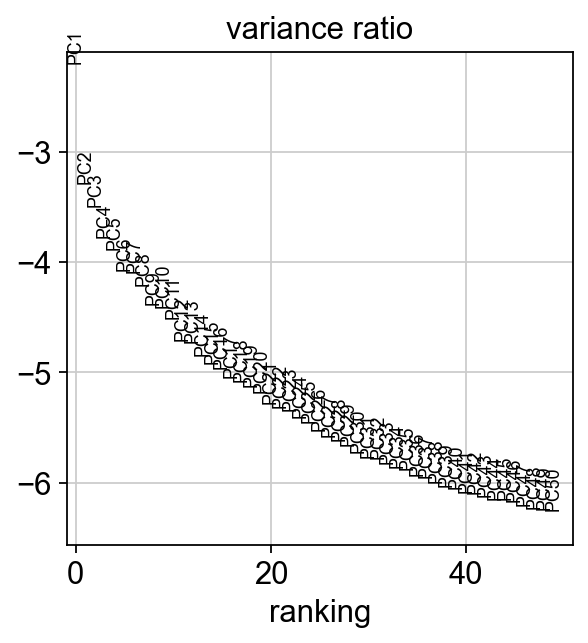

In [28]:
sc.pp.pca(adata, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

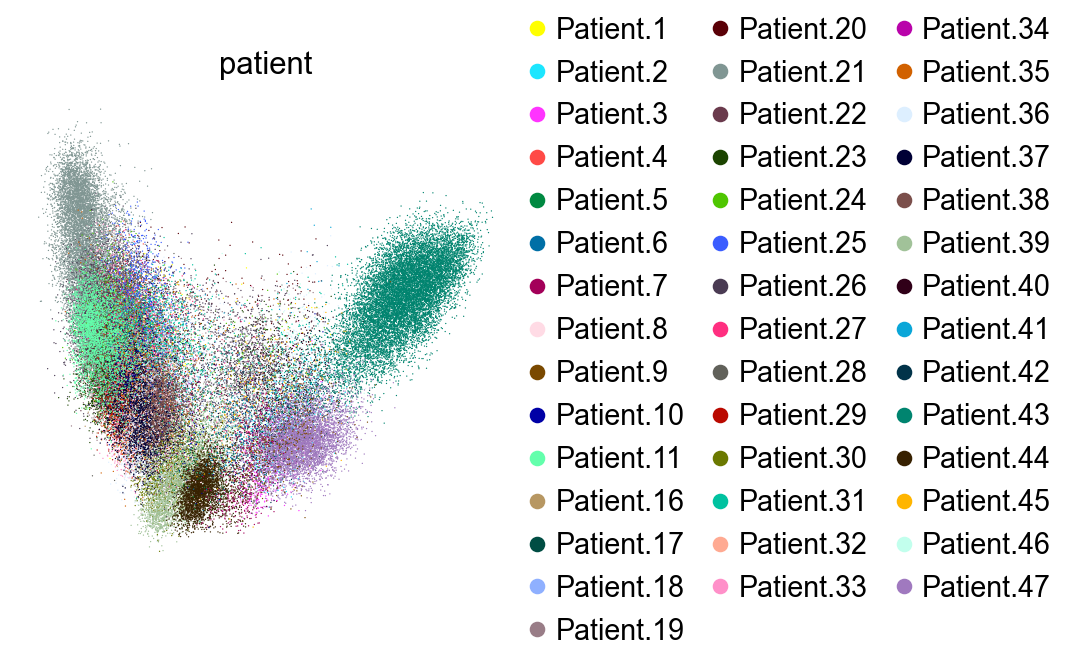

In [29]:
sc.pl.pca(adata, color="patient")

In [31]:
sc.external.pp.harmony_integrate(adata, key=["patient", "type"])

2025-10-24 14:26:00,077 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-24 14:26:00 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-10-24 14:26:05,065 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-24 14:26:05 | [INFO] sklearn.KMeans initialization complete.
2025-10-24 14:26:05,508 - harmonypy - INFO - Iteration 1 of 10
2025-10-24 14:26:05 | [INFO] Iteration 1 of 10
2025-10-24 14:26:44,385 - harmonypy - INFO - Iteration 2 of 10
2025-10-24 14:26:44 | [INFO] Iteration 2 of 10
2025-10-24 14:27:23,041 - harmonypy - INFO - Iteration 3 of 10
2025-10-24 14:27:23 | [INFO] Iteration 3 of 10
2025-10-24 14:28:01,923 - harmonypy - INFO - Iteration 4 of 10
2025-10-24 14:28:01 | [INFO] Iteration 4 of 10
2025-10-24 14:28:40,083 - harmonypy - INFO - Iteration 5 of 10
2025-10-24 14:28:40 | [INFO] Iteration 5 of 10
2025-10-24 14:29:32,697 - harmonypy - INFO - Converged after 5 iterations
2025-10-24 14:29:32 | [INFO] Converged after 5

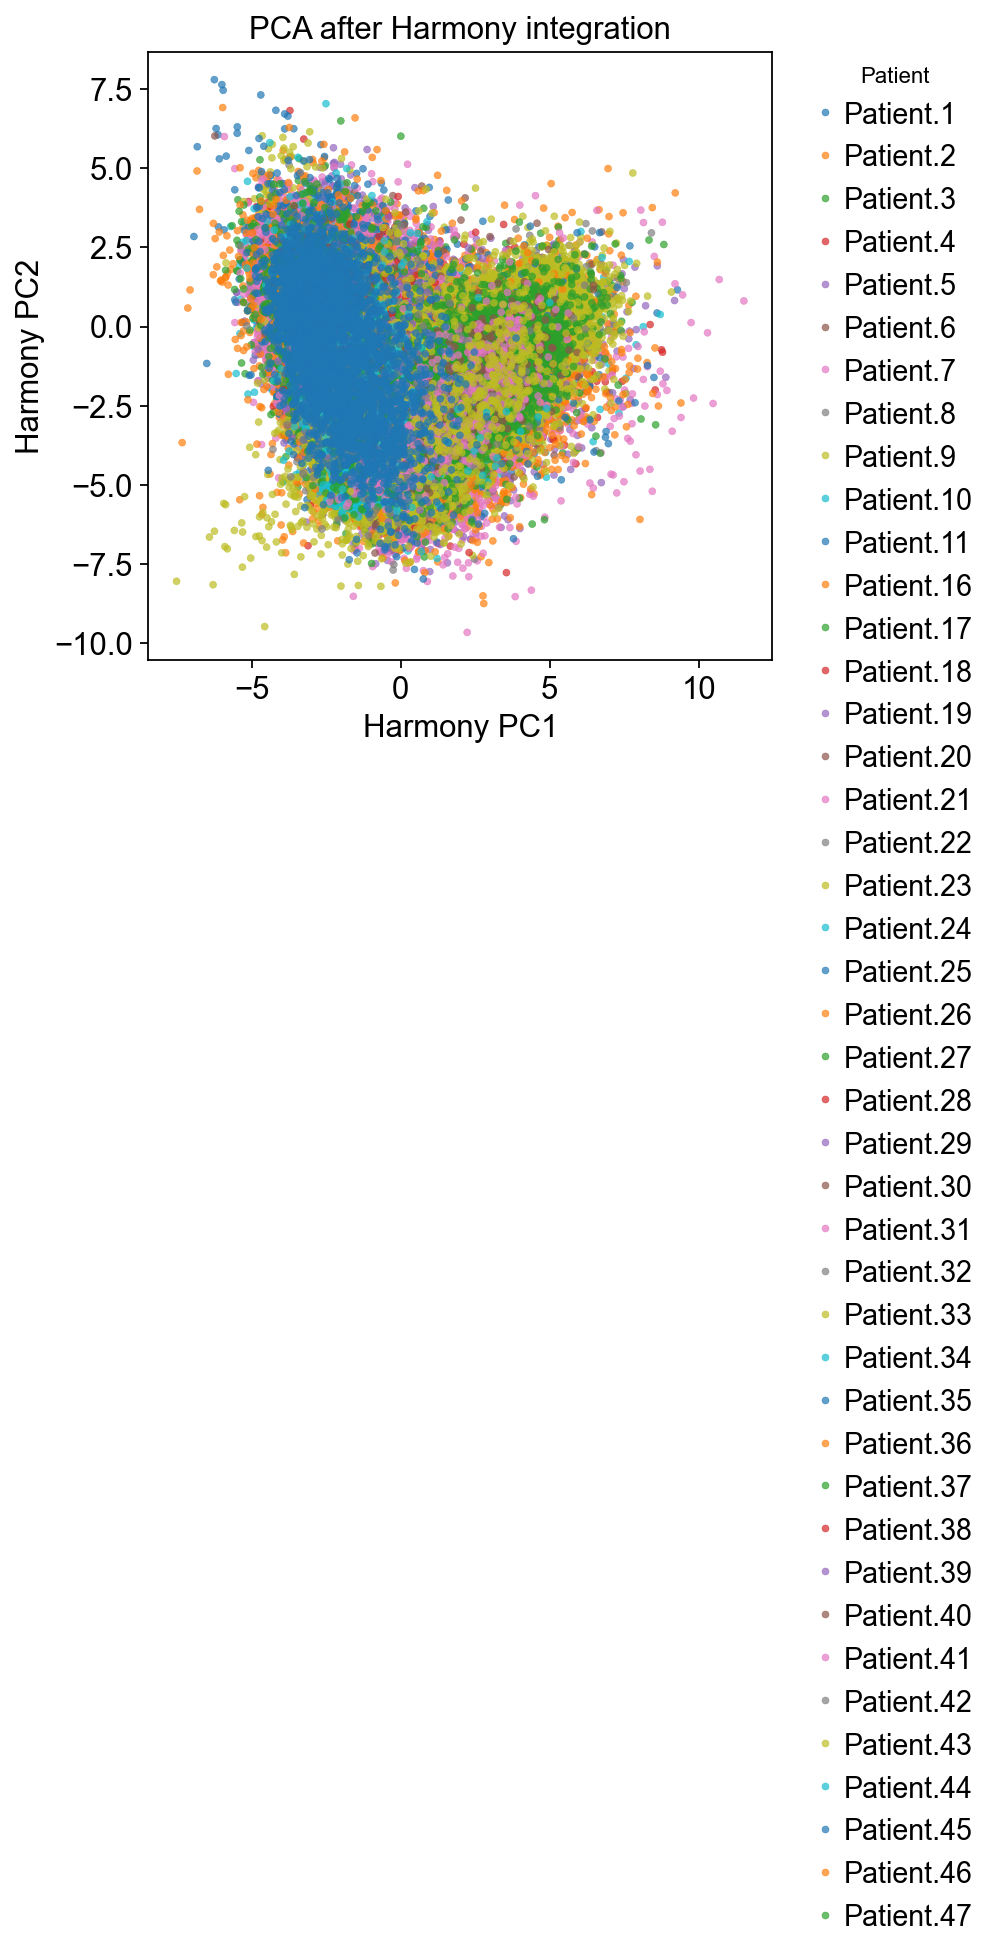

In [32]:
# plot corrected PCA using seaborn
fig = plt.figure(figsize=(5, 5))
sns.scatterplot(
    x=adata.obsm["X_pca_harmony"][:, 0],
    y=adata.obsm["X_pca_harmony"][:, 1],
    hue=adata.obs["patient"],
    palette="tab10",
    alpha=0.7,
    edgecolor=None,
    s=10,
)
plt.xlabel("Harmony PC1")
plt.ylabel("Harmony PC2")
plt.title("PCA after Harmony integration")
plt.legend(title="Patient", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(False)
plt.show()

In [33]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata)

computing neighbors
    finished (0:00:31)
computing UMAP
    finished (0:01:19)


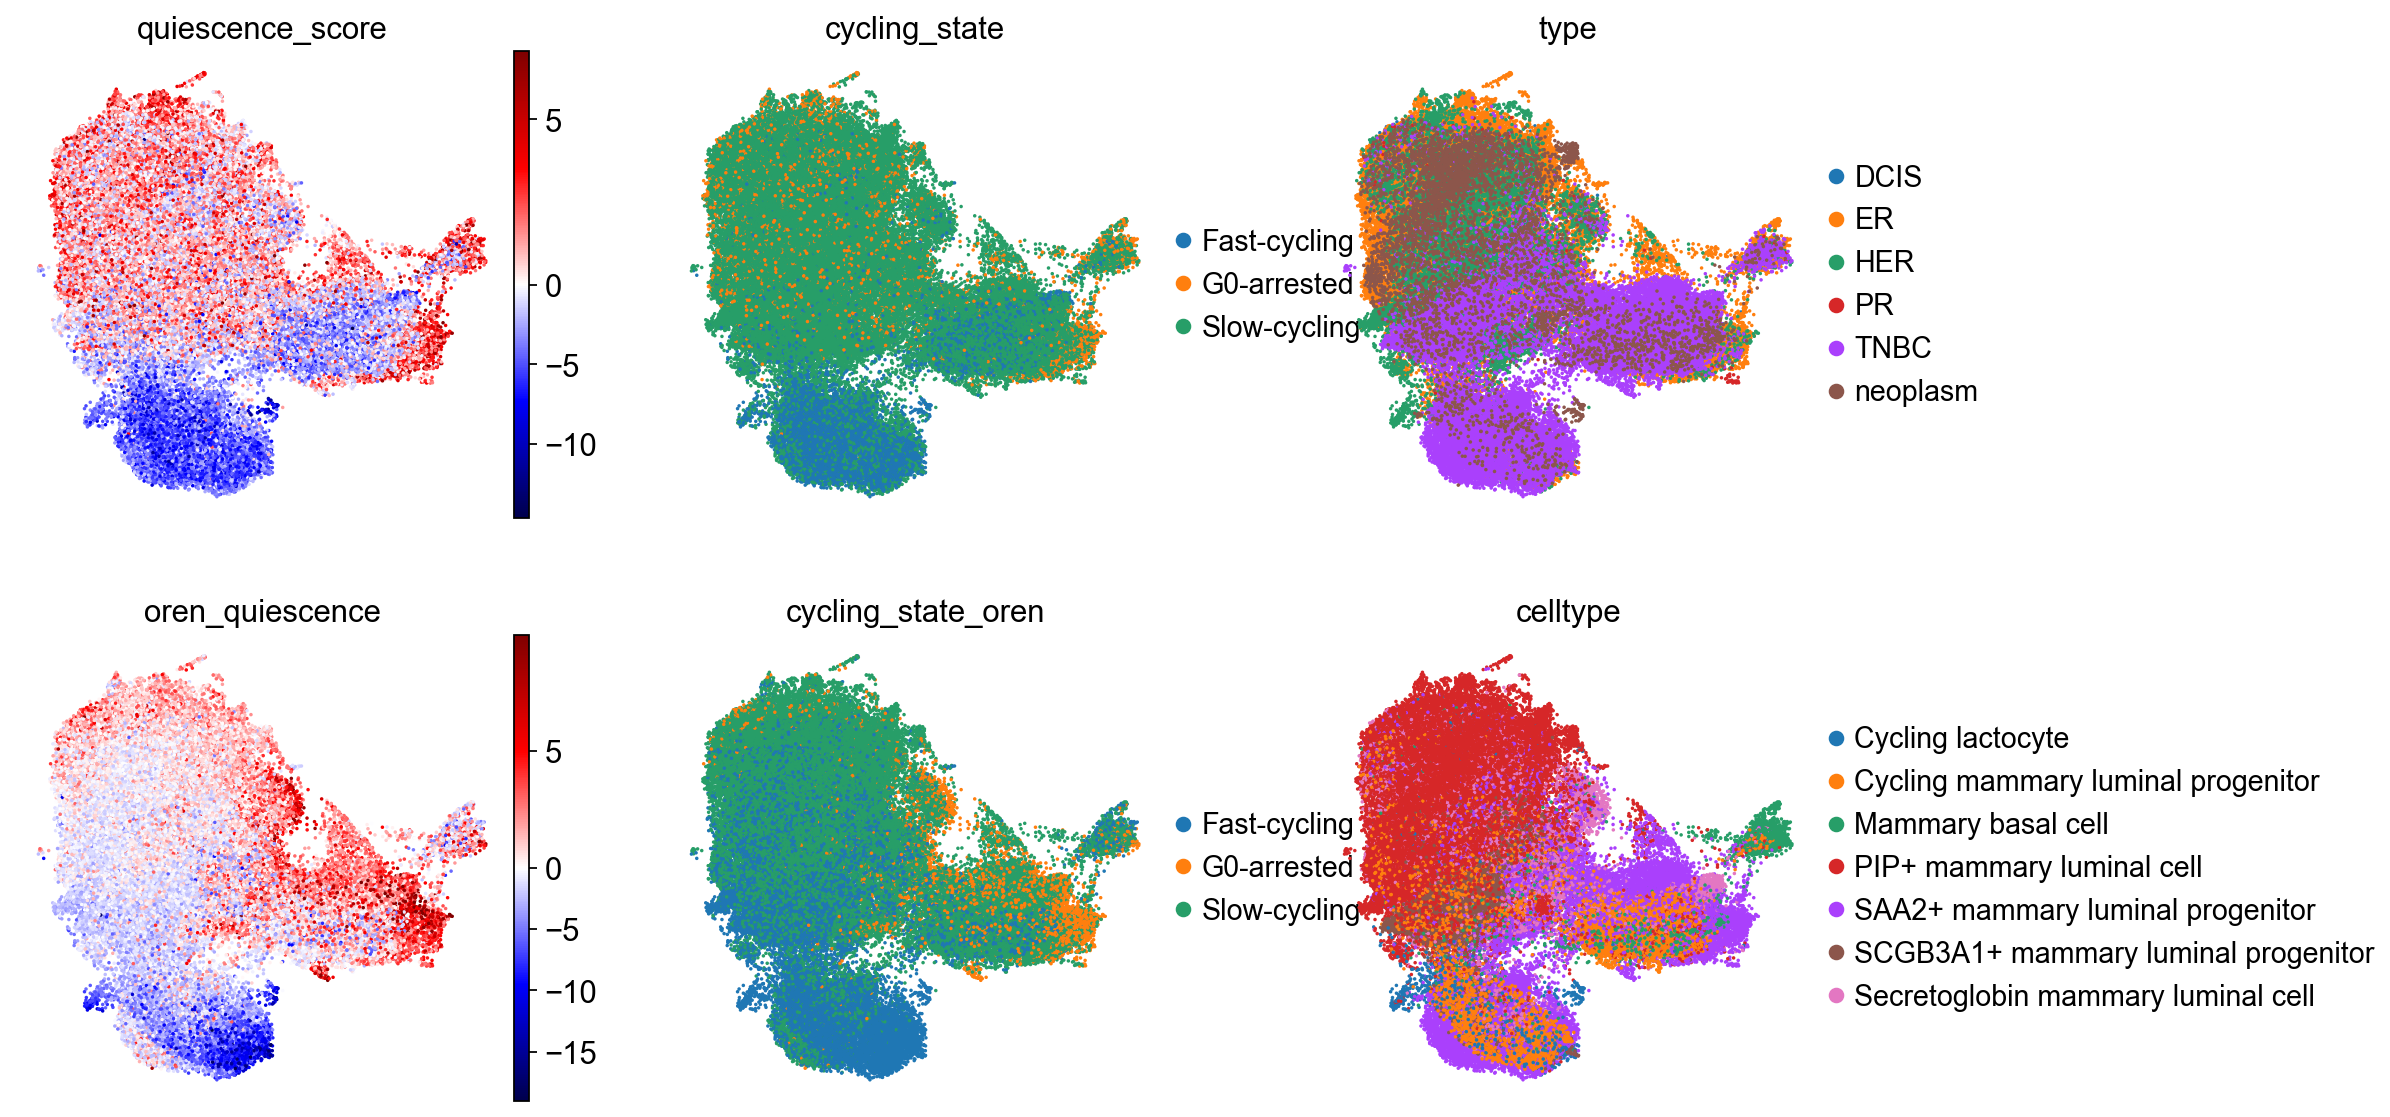

In [34]:
sc.pl.umap(
    adata,
    color=[
        "quiescence_score",
        "cycling_state",
        "type",
        "oren_quiescence",
        "cycling_state_oren",
        "celltype",
    ],
    cmap="seismic",
    vcenter=0,
    ncols=3,
    sort_order=False,
    vmax="p99.9",
    s=10,
)

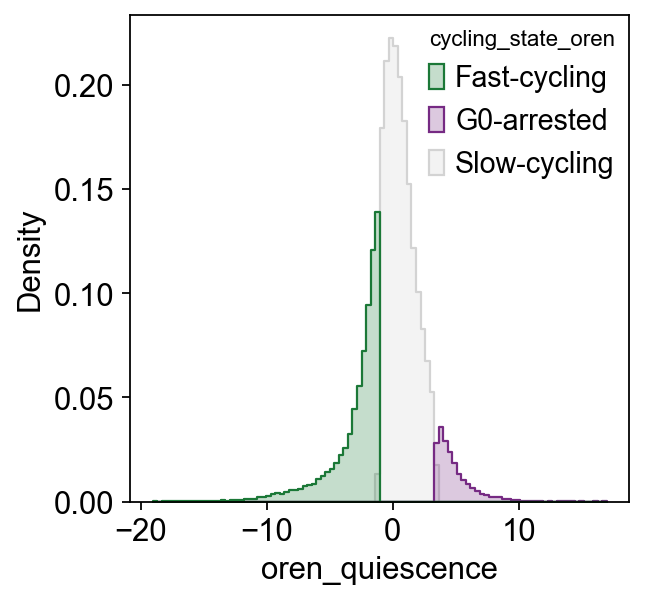

In [35]:
sns.histplot(
    data=adata.obs,
    x="oren_quiescence",
    hue="cycling_state_oren",
    element="step",
    stat="density",
    common_norm=True,
    palette=cycling_colors,
    bins=100,
)
plt.grid(False)

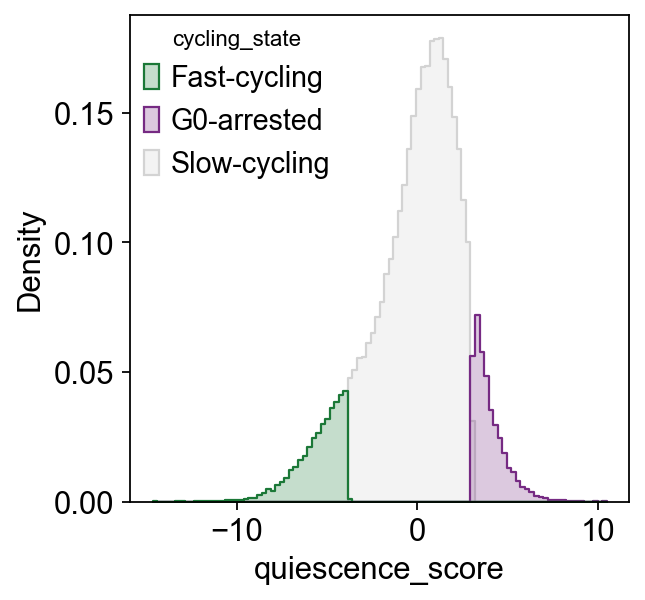

In [36]:
sns.histplot(
    data=adata.obs,
    x="quiescence_score",
    hue="cycling_state",
    element="step",
    stat="density",
    common_norm=True,
    palette=cycling_colors,
    bins=100,
)
plt.grid(False)

## Recalculation of UMAP on the full dataset

In [37]:
adata_full.obs["oren_quiescence"] = adata.obs["oren_quiescence"].reindex(adata_full.obs_names)
adata_full.obs["cycling_state_oren"] = adata.obs["cycling_state_oren"].reindex(adata_full.obs_names)

In [38]:
adata_full.obsm["X_pca"] = adata_full.obsm.pop("PCA")
adata_full.obsm["X_umap"] = adata_full.obsm.pop("UMAP")

In [39]:
if isinstance(adata_full.obsm["X_umap"], pd.DataFrame):
    adata_full.obsm["X_umap"] = adata_full.obsm["X_umap"].to_numpy()

if isinstance(adata_full.obsm["X_pca"], pd.DataFrame):
    adata_full.obsm["X_pca"] = adata_full.obsm["X_pca"].to_numpy()

In [ ]:
col = "cycling_state_oren"
adata_full.obs[col] = adata_full.obs[col].astype(str)
adata_full.obs[col].replace("nan", np.nan, inplace=True)
adata_full.obs[col].dtype
adata_full.obs[col].unique()

array(['Slow-cycling', 'G0-arrested', nan, 'Fast-cycling'], dtype=object)

In [41]:
adata_full.uns["cycling_state_oren_colors"] = [
    "#1B7837",  # Fast-cycling
    "#762A83",  # G0-arrested
    "#BEBADA",  # Slow-cycling
]

... storing 'cycling_state_oren' as categorical


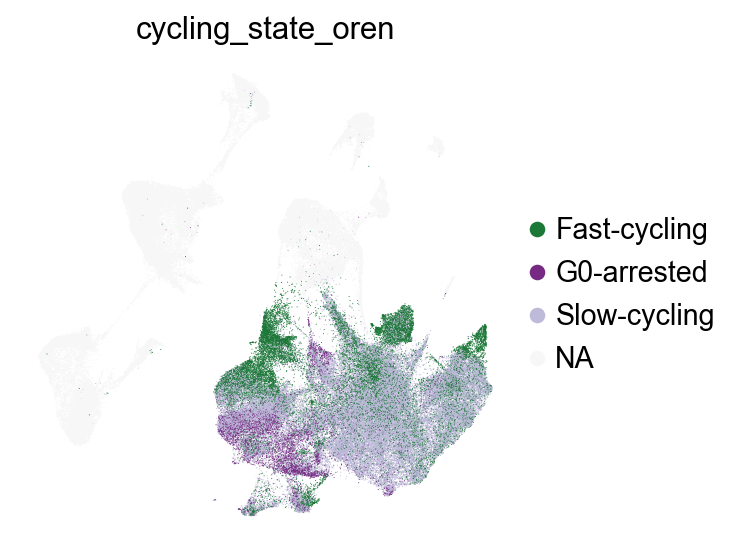

In [42]:
sc.pl.umap(
    adata_full,
    color="cycling_state_oren",
    sort_order=False,
    na_color="#F7F7F7",
)

In [43]:
sc.pp.filter_genes(adata_full, min_cells=50)
sc.pp.normalize_total(adata_full, target_sum=None)
sc.pp.log1p(adata_full)
sc.pp.highly_variable_genes(adata_full, n_top_genes=3000, flavor="cell_ranger", batch_key="patient")

filtered out 9642 genes that are detected in less than 50 cells
normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:09)


In [44]:
sc.pp.pca(adata_full, use_highly_variable=True)

computing PCA
    with n_comps=50
    finished (0:00:25)


In [45]:
sc.external.pp.harmony_integrate(adata_full, ["patient", "type"], max_iter_harmony=20)

2025-10-24 14:32:21,414 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-24 14:32:21 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-10-24 14:32:30,301 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-24 14:32:30 | [INFO] sklearn.KMeans initialization complete.
2025-10-24 14:32:31,033 - harmonypy - INFO - Iteration 1 of 10
2025-10-24 14:32:31 | [INFO] Iteration 1 of 10


2025-10-24 14:33:45,661 - harmonypy - INFO - Iteration 2 of 10
2025-10-24 14:33:45 | [INFO] Iteration 2 of 10
2025-10-24 14:35:04,238 - harmonypy - INFO - Iteration 3 of 10
2025-10-24 14:35:04 | [INFO] Iteration 3 of 10
2025-10-24 14:36:23,314 - harmonypy - INFO - Iteration 4 of 10
2025-10-24 14:36:23 | [INFO] Iteration 4 of 10
2025-10-24 14:37:40,881 - harmonypy - INFO - Iteration 5 of 10
2025-10-24 14:37:40 | [INFO] Iteration 5 of 10
2025-10-24 14:39:05,405 - harmonypy - INFO - Iteration 6 of 10
2025-10-24 14:39:05 | [INFO] Iteration 6 of 10
2025-10-24 14:40:20,409 - harmonypy - INFO - Iteration 7 of 10
2025-10-24 14:40:20 | [INFO] Iteration 7 of 10
2025-10-24 14:41:34,809 - harmonypy - INFO - Iteration 8 of 10
2025-10-24 14:41:34 | [INFO] Iteration 8 of 10
2025-10-24 14:42:33,625 - harmonypy - INFO - Iteration 9 of 10
2025-10-24 14:42:33 | [INFO] Iteration 9 of 10
2025-10-24 14:43:25,917 - harmonypy - INFO - Converged after 9 iterations
2025-10-24 14:43:25 | [INFO] Converged after 9

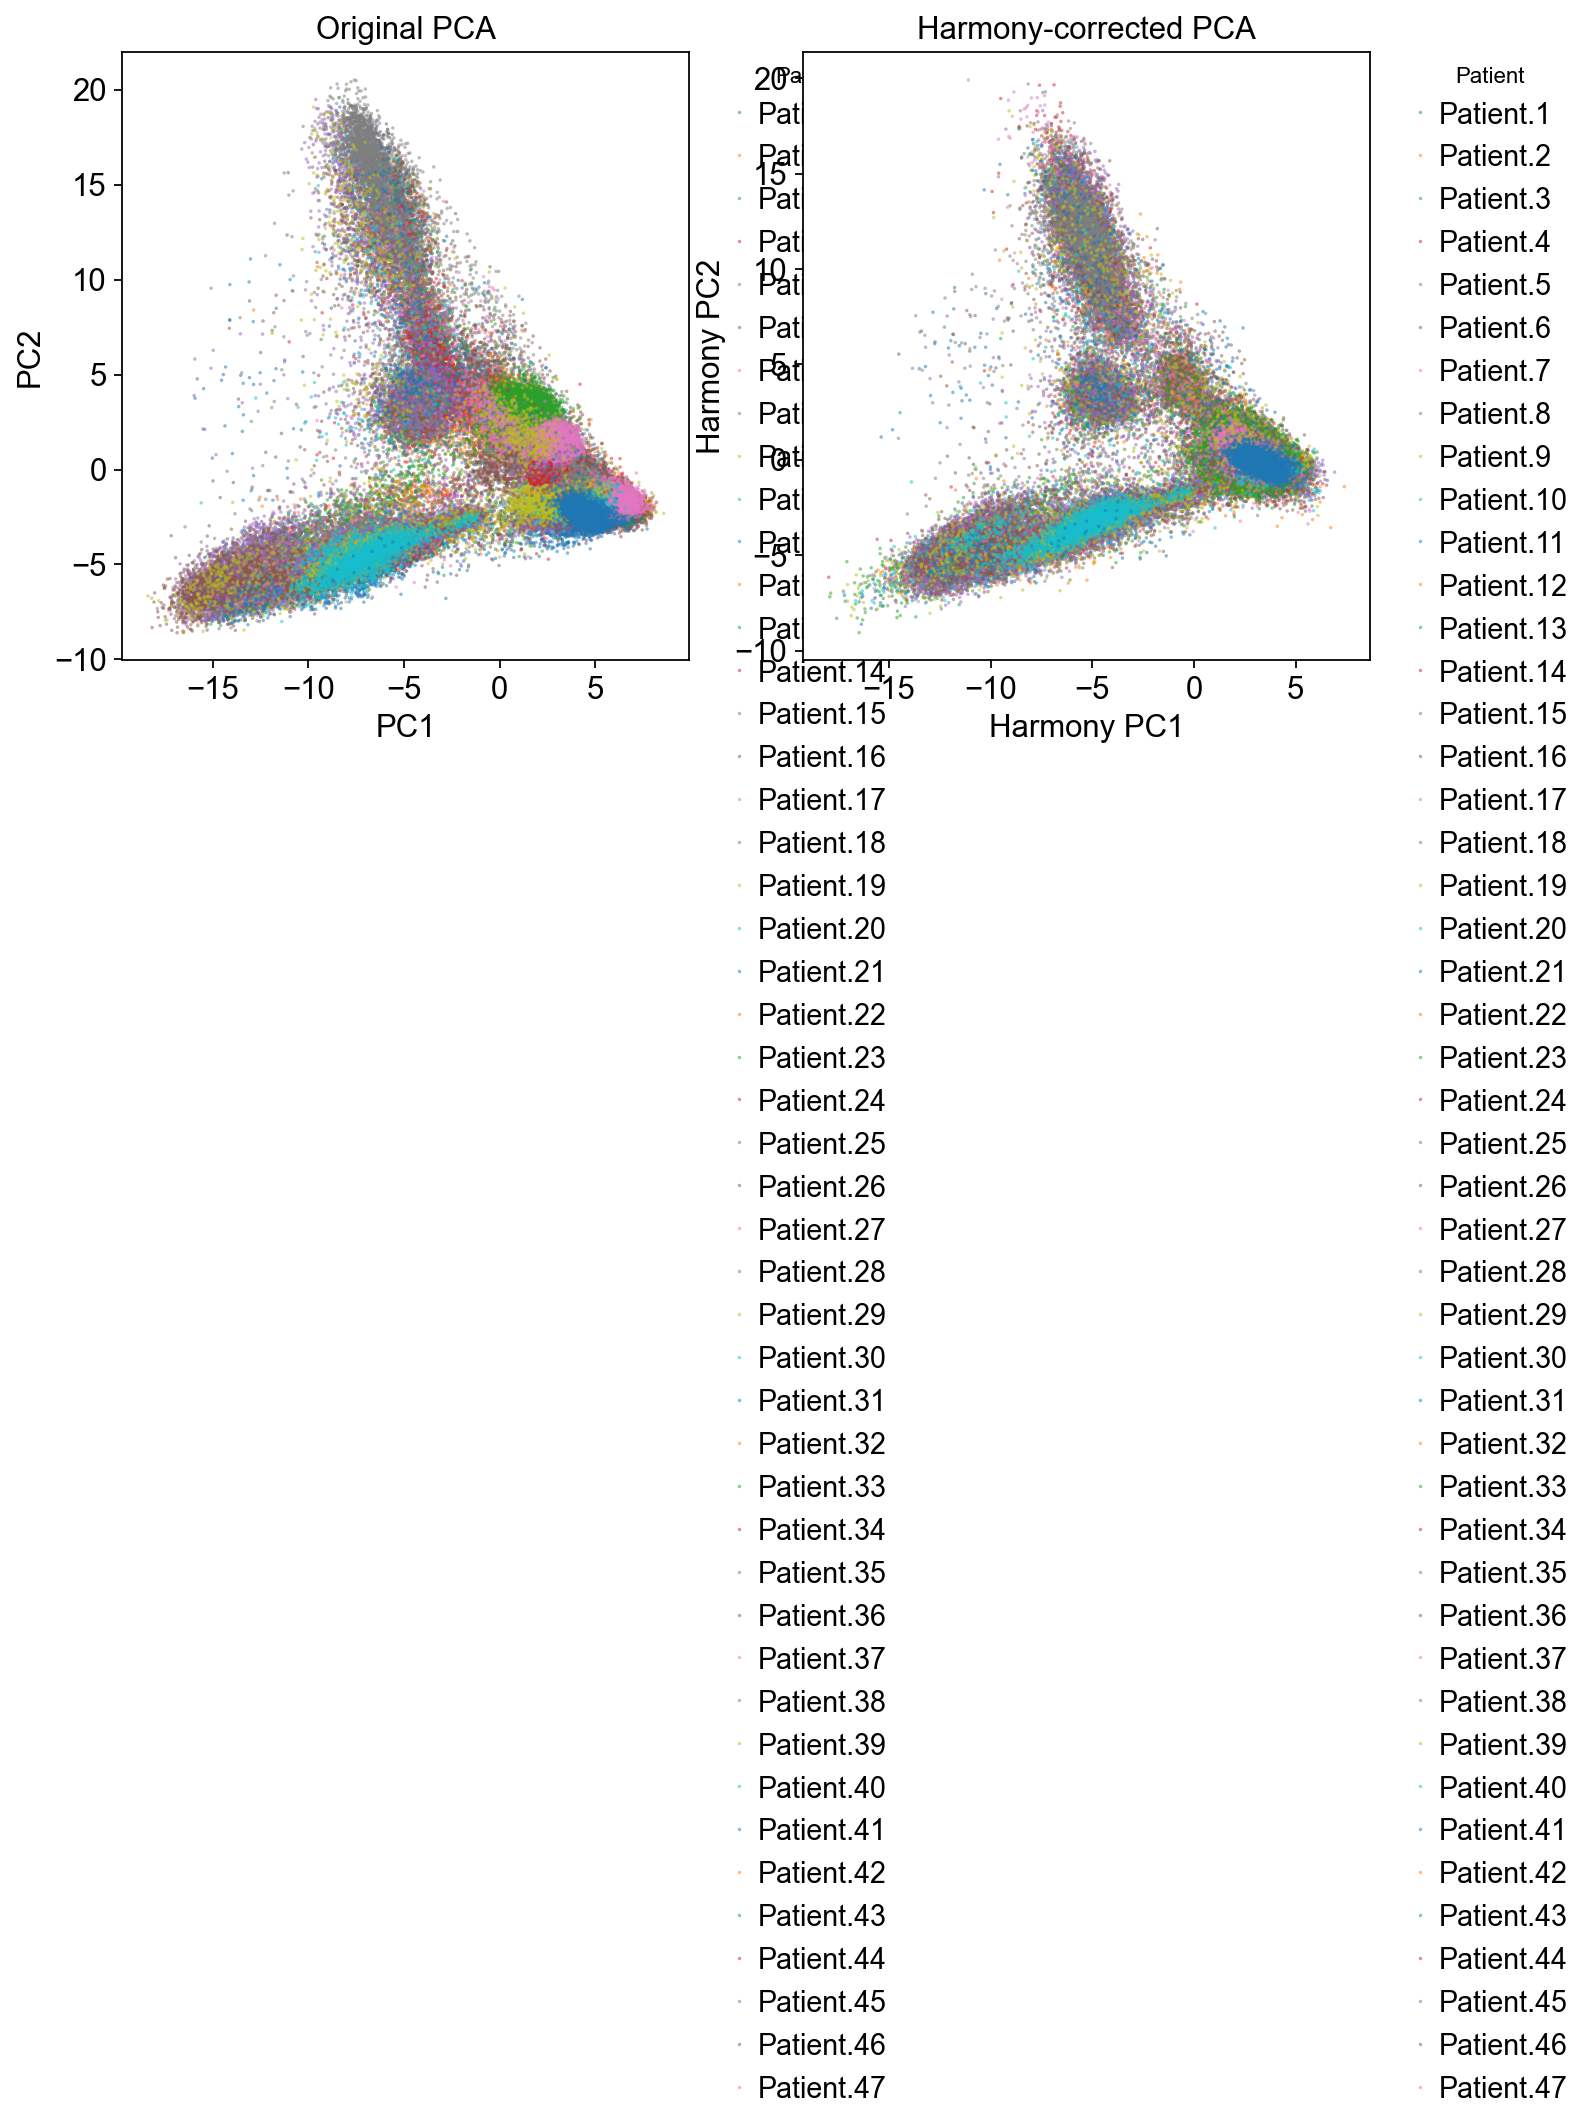

In [46]:
# Plot original PCA and Harmony-corrected PCA side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)

# Original PCA
sns.scatterplot(
    ax=axes[0],
    x=adata_full.obsm["X_pca"][:, 0],
    y=adata_full.obsm["X_pca"][:, 1],
    hue=adata_full.obs["patient"],
    palette="tab10",
    alpha=0.5,
    edgecolor=None,
    s=2,
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Original PCA")
axes[0].legend(title="Patient", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[0].grid(False)

# Harmony-corrected PCA
sns.scatterplot(
    ax=axes[1],
    x=adata_full.obsm["X_pca_harmony"][:, 0],
    y=adata_full.obsm["X_pca_harmony"][:, 1],
    hue=adata_full.obs["patient"],
    palette="tab10",
    alpha=0.5,
    edgecolor=None,
    s=2,
)
axes[1].set_xlabel("Harmony PC1")
axes[1].set_ylabel("Harmony PC2")
axes[1].set_title("Harmony-corrected PCA")
axes[1].legend(title="Patient", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [47]:
sc.pp.neighbors(adata_full, n_neighbors=30, use_rep="X_pca_harmony")
sc.tl.umap(adata_full)

computing neighbors
    finished (0:00:35)
computing UMAP
    finished (0:02:59)


In [48]:
adata_full.obs = adata_full.obs.rename(
    columns={
        "QuiescenceScore": "quiescence_score",
        "QuiescenceStatus": "cycling_state"
    }
)

# replace values in QuiescenceStatus
adata_full.obs["cycling_state"] = adata_full.obs["cycling_state"].replace(
    {"Quiescent": "G0-arrested", "Proliferating": "Fast-cycling"}
)

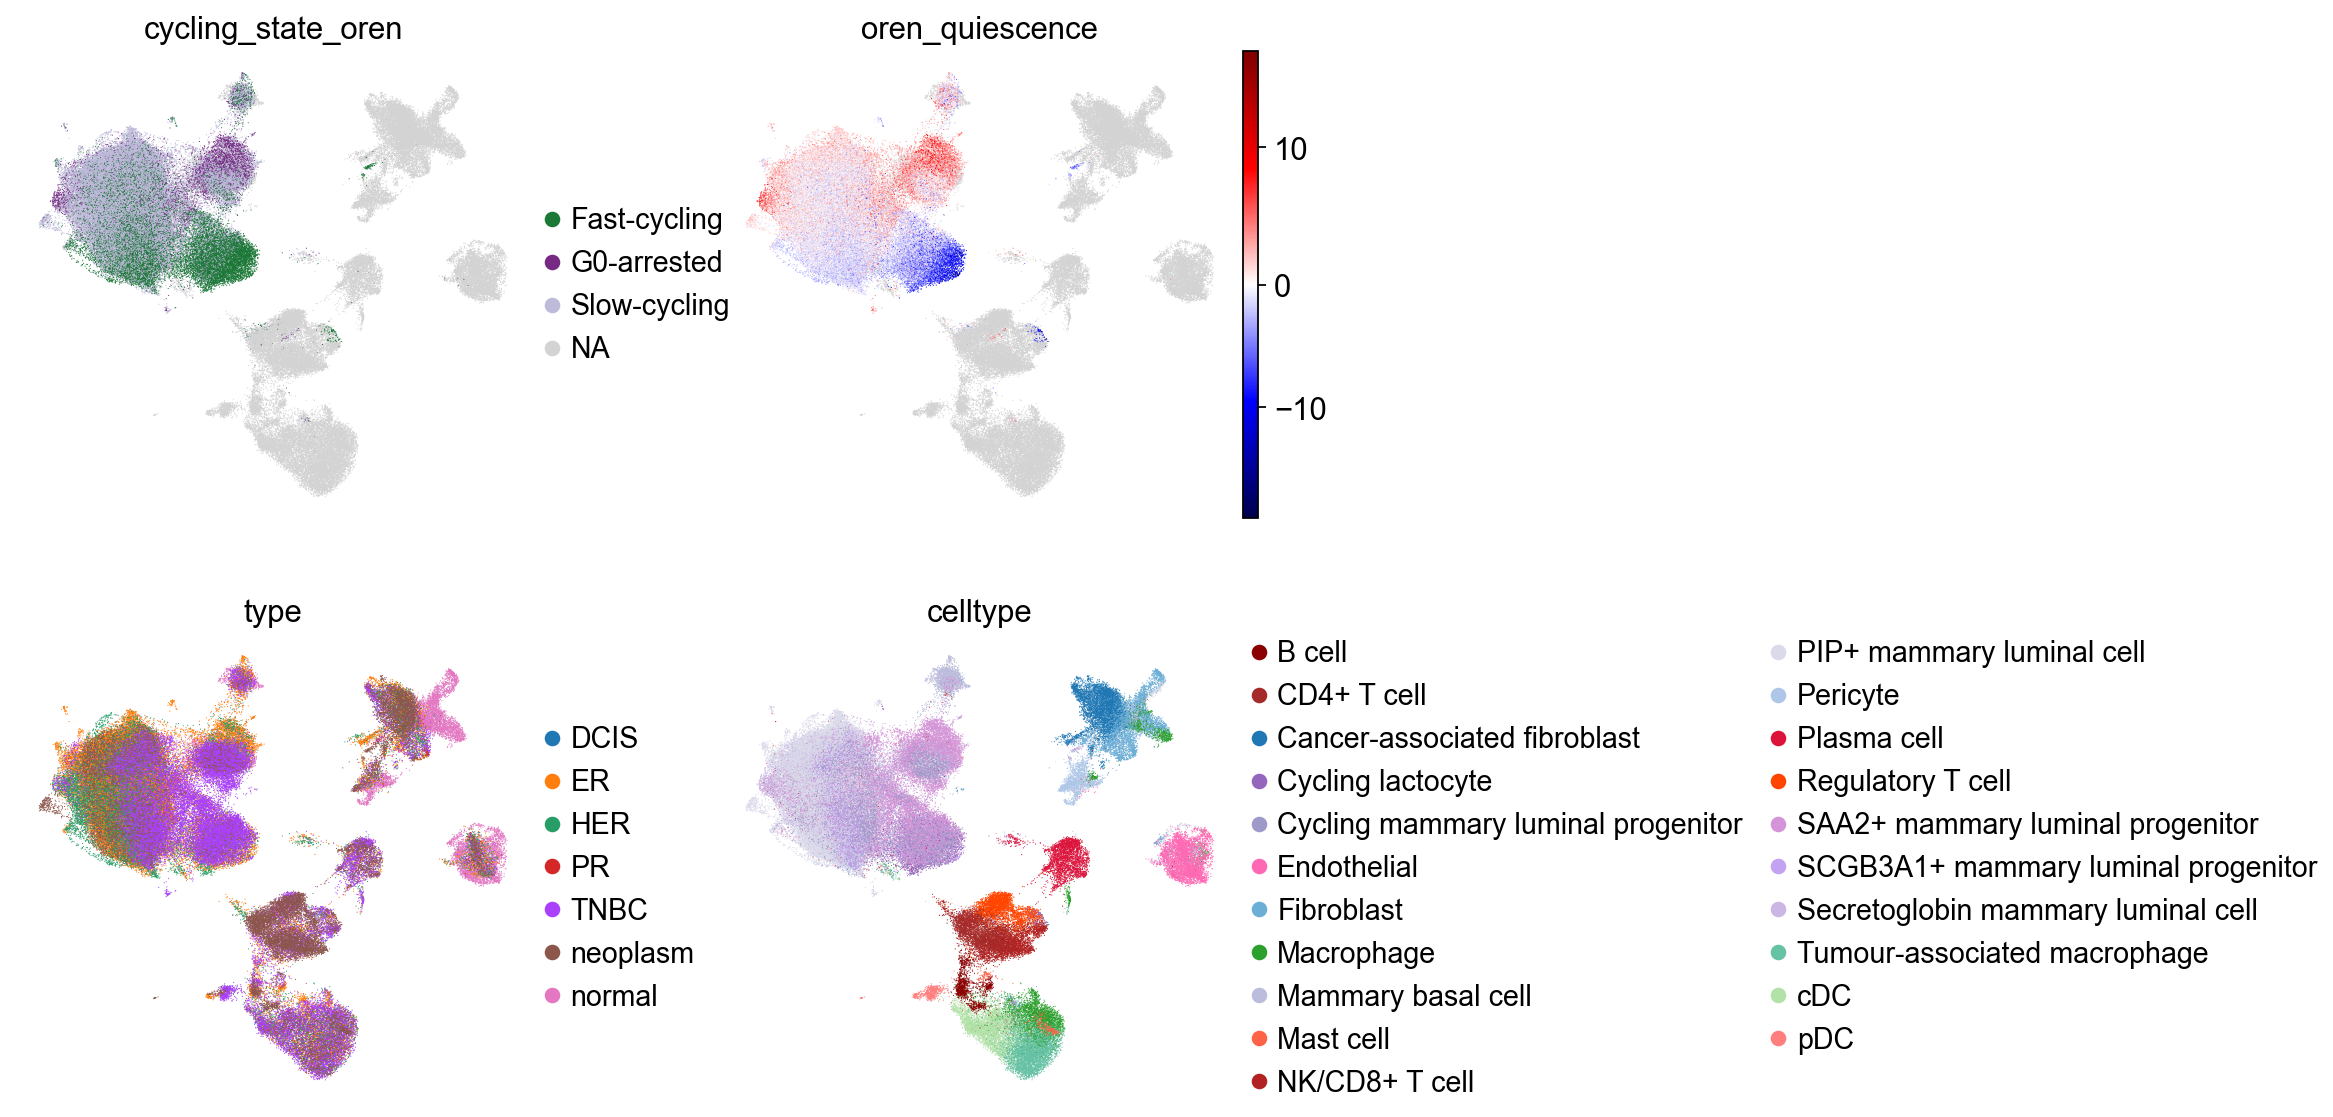

In [60]:
sc.pl.umap(
    adata_full,
    color=["cycling_state_oren", "oren_quiescence", "type", "celltype"],
    cmap="seismic",
    vcenter=0,
    ncols=2,
    sort_order=False,
    s=1,
    wspace=0.25,
    save="_harmony_new_scores.pdf",
)

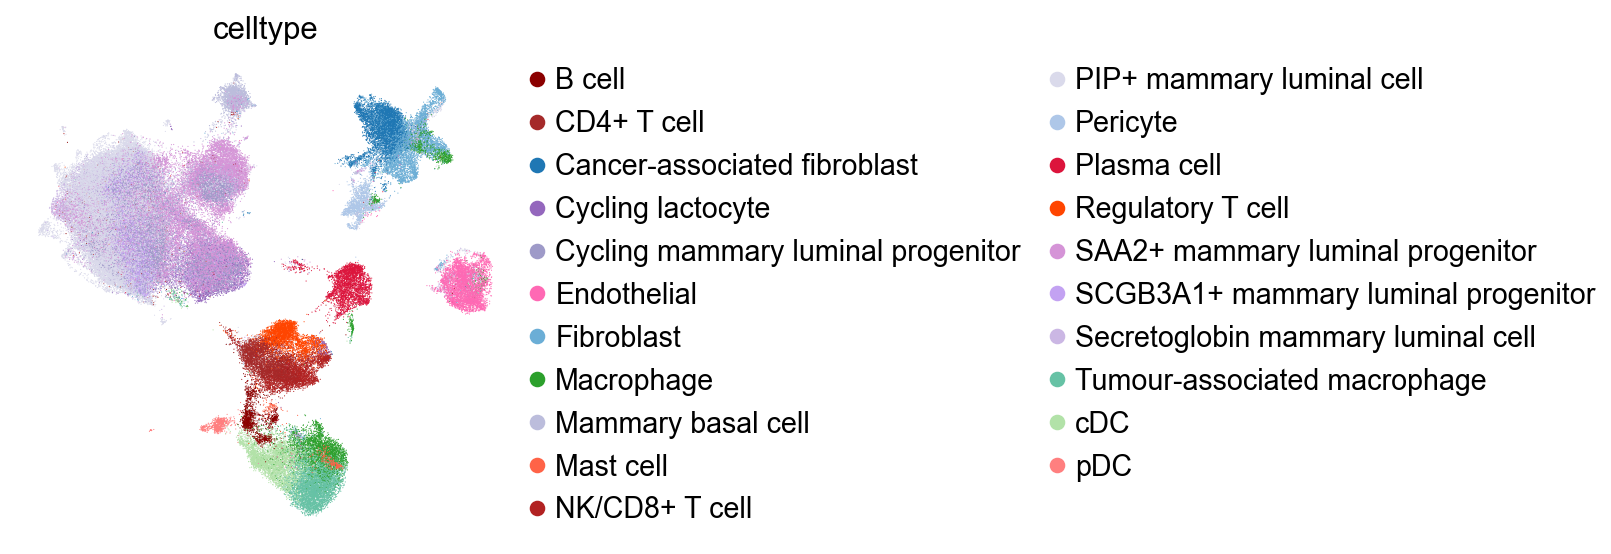

In [61]:
celltype_palette = {
    "B cell": "#8B0000",
    "CD4+ T cell": "#A52A2A",
    "Cancer-associated fibroblast": "#1f77b4",
    "Cycling lactocyte": "#9467bd",
    "Cycling mammary luminal progenitor": "#9e9ac8",
    "Endothelial": "#FF69B4",
    "Fibroblast": "#6baed6",
    "Macrophage": "#2ca02c",
    "Mammary basal cell": "#bcbddc",
    "Mast cell": "#FF6347",
    "NK/CD8+ T cell": "#B22222",
    "PIP+ mammary luminal cell": "#dadaeb",
    "Pericyte": "#aec7e8",
    "Plasma cell": "#DC143C",
    "Regulatory T cell": "#FF4500",
    "SAA2+ mammary luminal progenitor": "#d594d7",
    "SCGB3A1+ mammary luminal progenitor": "#c3a2f2",
    "Secretoglobin mammary luminal cell": "#cbb7e4",
    "Tumour-associated macrophage": "#66c2a5",
    "cDC": "#b2e2a8",
    "pDC": "#FF7F7F",
}

sc.pl.umap(
    adata_full,
    color="celltype",
    palette=celltype_palette,
    sort_order=False,
    s=1,
)

In [51]:
adata_full.write_h5ad(data_dir + "adata_full_harmony_integration.h5ad")